# First use the HPLC_molecule_creation script if it is the frist analysis load
## Load Metadata

The spreadsheet `metadata_v2.xlsx` defines the initial concentrations of all molecules present in the respective assay. 
Products should be added with a concentration of 0. Empty cells are not added to the analyzer.

In [ ]:
import pandas as pd
from pathlib import Path

# load metadata as dataframe
metadata_path = "input/metadata_v2.xlsx"
metadata_df = pd.read_excel(metadata_path)

# set 'experiment_name' as index
metadata_df.set_index("experiment_name", inplace=True)

metadata_df

,reaction_vol [mL],temperature,pH,ScADK,EbPPK,tmmcGAS,EaGK,Ado,AMP,ADP,ATP,GMP,GDP,GTP,Gua,TrisHCL,MgCl2,PolyP
experiment_name,,,,,,,,,,,,,,,,,,
20241030 Ado ATP 1,1,37,8,NaN,0.00001,NaN,NaN,NaN,5,NaN,NaN,5,NaN,NaN,NaN,50,10,50
20241030 Ado ATP 2,1,37,8,NaN,0.00001,NaN,NaN,NaN,5,NaN,NaN,5,NaN,NaN,NaN,50,10,50
20241030 Ado ATP 3,1,37,8,NaN,0.00001,NaN,NaN,NaN,5,NaN,NaN,5,NaN,NaN,NaN,50,10,50



## Load Molecules

In [ ]:
from chromhandler import Handler, Molecule, Protein, to_enzymeml
from pathlib import Path
import numpy as np
from utility import plot_replicates

# create list to add molecules to
molecules = []

# define path to the calibration molecules
molecule_dir = Path("result/calib_molecules/20251016standards")

# define a dictionary with retention time to updates
retention_update = {"ATP": 5.55}

# loop over all the json files in the calibration molecules folder
# and create molecule objects
for molecule_path in molecule_dir.glob("*.json"):
    molecule = Molecule.read_json(molecule_path)
    molecule.retention_time = retention_update[molecule.id]
    molecules.append(molecule)

print(f"Loaded {len(molecules)} with IDs {[m.id for m in molecules]}")


Loaded 8 with IDs ['ATP', 'AMP', 'GMP', 'GTP', 'ADP', 'Gua', 'Ado', 'GDP']


## Load Proteins

In [36]:
proteins = []

for protein_path in Path("result/proteins").glob("*.json"):
    protein = Protein.read_json(protein_path)
    proteins.append(protein)

print(f"Loaded {len(proteins)} with names {[p.name for p in proteins]}")

Loaded 4 with names ['ScADK', 'EaGK', 'tmmcGAS', 'EbPPK']


#Filter the molecules based on the the 

# Process timecours data 

In [ ]:
sample_dir = Path("data/time_sample/20241030 Ado ATP")
print(f"Found {len(list(sample_dir.iterdir()))} time samples in {sample_dir}")

# loop over all the time samples and create the ChromAnalyzer objects
handlers = []
for time_samples in sample_dir.iterdir():
    path = str(time_samples)
    analyzer = Handler.read_agilent(
        path=path,
        ph=metadata_df.loc[str(time_samples.name), "pH"],
        temperature=metadata_df.loc[str(time_samples.name), "temperature"],
        mode="timecourse",
    )

    # add molecule data to the analyzer
    for molecule in molecules:
        init_conc = metadata_df.loc[str(time_samples.name), molecule.id]

        # set constant molecules (concentration does not change over time)
        if molecule.id in ["MgCl2", "TrisHCL"]:
            molecule.constant = True

        # if init conc not nan, add to analyzer
        if not np.isnan(init_conc):
            analyzer.add_molecule(
                molecule,
                init_conc=metadata_df.loc[str(time_samples.name), molecule.id],
                conc_unit="umol / L",
            )

    # add protein data to the analyzer
    for protein in proteins:
        init_conc = metadata_df.loc[str(time_samples.name), protein.name]

        # if init conc not nan, add to analyzer
        if not np.isnan(init_conc):
            analyzer.add_protein(
                protein,
                init_conc=metadata_df.loc[str(time_samples.name), protein.name],
                conc_unit="umol / L",
            )

    analyzer.assign_all_peaks()

    handlers.append(analyzer)

Found 3 time samples in data/time_sample/20241030 Ado ATP


              🎯 Peak Assignment Summary of 20241030 Ado ATP 1              
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Molecule                      ┃  Status   ┃ Details                      ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ AMP (Adenosine Monophosphate) │ ❌ Failed │ (0/8) peaks at 2.0 ± 0.4 min │
│ GMP (Guanosine Monophosphate) │ ❌ Failed │ (0/8) peaks at 2.0 ± 0.4 min │
└───────────────────────────────┴───────────┴──────────────────────────────┘

              🎯 Peak Assignment Summary of 20241030 Ado ATP 3              
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Molecule                      ┃  Status   ┃ Details                      ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ AMP (Adenosine Monophosphate) │ ❌ Failed │ (0/8) peaks at 2.0 ± 0.4 min │
│ GMP (Guanosine Monophosphate) │ ❌ Failed │ (0/8) peaks at 2.0 ± 0.4 min │
└───────────────────────────────┴───────────┴──────────────────────────────┘

          🎯 Peak Assignment Summary of 20241030 Ado ATP 2           
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┓
┃ Molecule                      ┃   Status   ┃ Details              ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━┩
│ AMP (Adenosine Monophosphate) │ 🟡 Partial │ (1/8) peaks assigned │
│ GMP (Guanosine Monophosphate) │ 🟡 Partial │ (1/8) peaks assigned │
└───────────────────────────────┴────────────┴──────────────────────┘

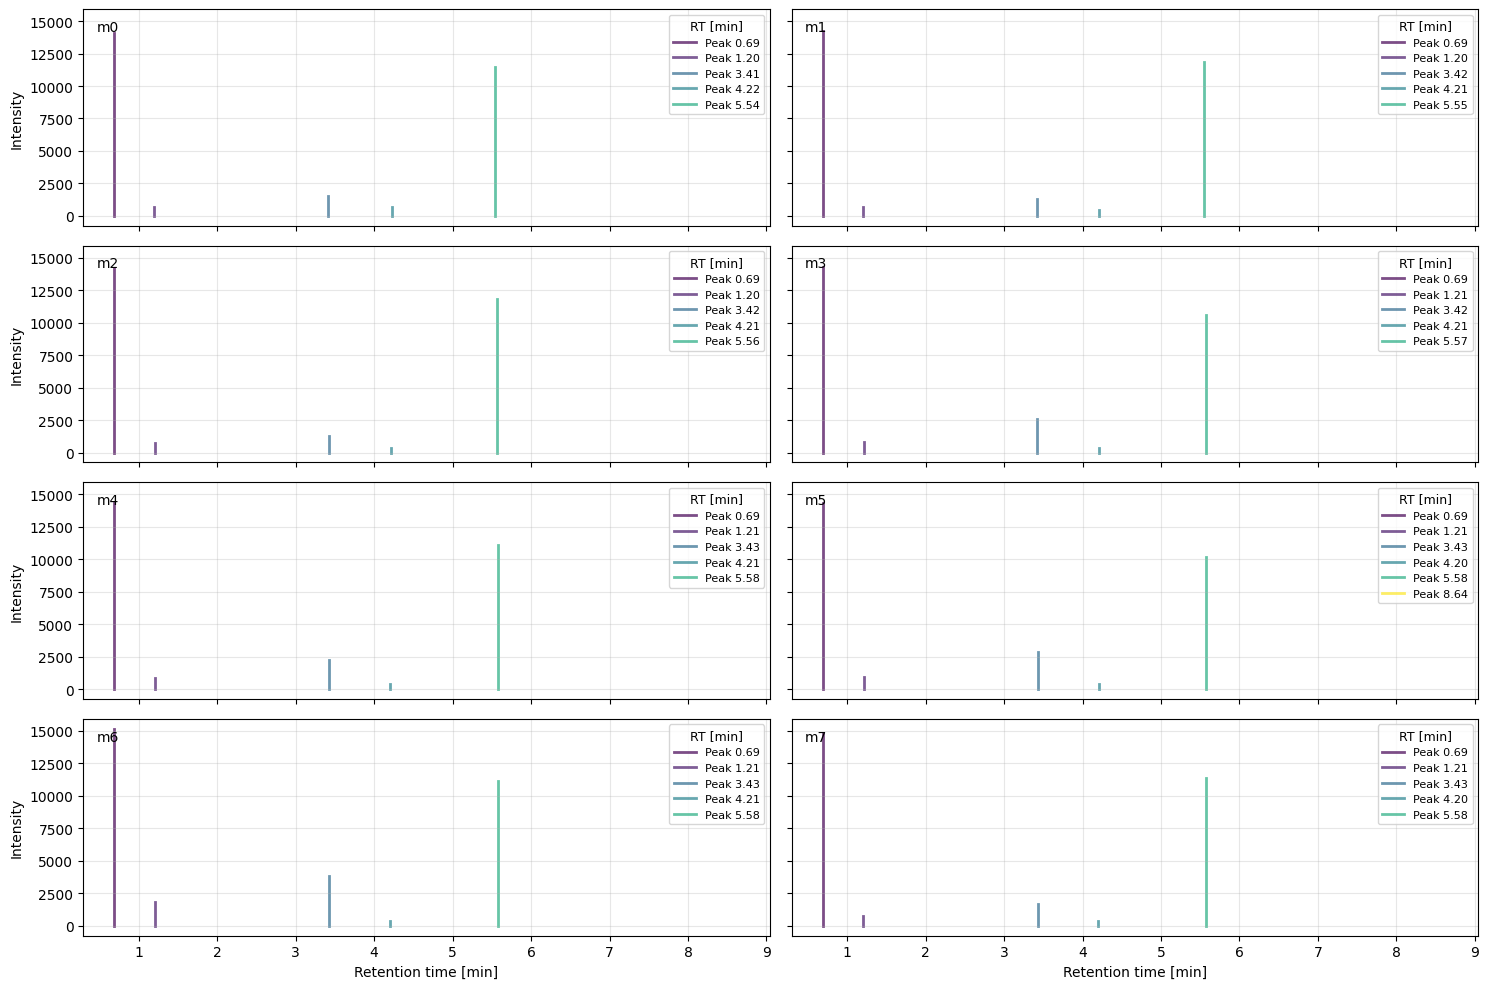

In [42]:
handlers[0].visualize()


## Create EnzymeML Document including 3 replicates



In [39]:
import pyenzyme as pe

# add the metadata to the timecourse data
timecourse_enzymeML = to_enzymeml(
    document_name="MjNK_20mg_L_HEPES_50mM_NaCl_150mM",
    handlers=handlers,
    calculate_concentration=True,
    extrapolate=False,
)

# add vessel
vessel = pe.Vessel(
    id="v1",
    name="Eppendorf Tube",
    volume="1",
    unit="ml",
)
timecourse_enzymeML.vessels = [vessel]


# identify replicates
timecourse_enzymeML = pe.group_measurements(timecourse_enzymeML, attribute="prepared")

# show summary of document
pe.summary(timecourse_enzymeML)

# save the enzymeML document to file
pe.write_enzymeml(
    timecourse_enzymeML, f"result/enzymeML/{timecourse_enzymeML.name}.json"
)

HTML(value='<h3>📄 Document Overview</h3><br><b>Name:</b> MjNK_20mg_L_HEPES_50mM_NaCl_150mM<br><b>Version:</b> …

Accordion(children=(HTML(value='<table border="1" class="dataframe">\n  <thead>\n    <tr style="text-align: ri…

EnzymeML document written to result/enzymeML/MjNK_20mg_L_HEPES_50mM_NaCl_150mM.json

## Visualize

For visualization the build-in `plot` method of the `pyenzyme` package can be used.

/Users/max/miniconda3/envs/chromhandler/lib/python3.12/site-packages/pyenzyme/plotting/static.py:282: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(


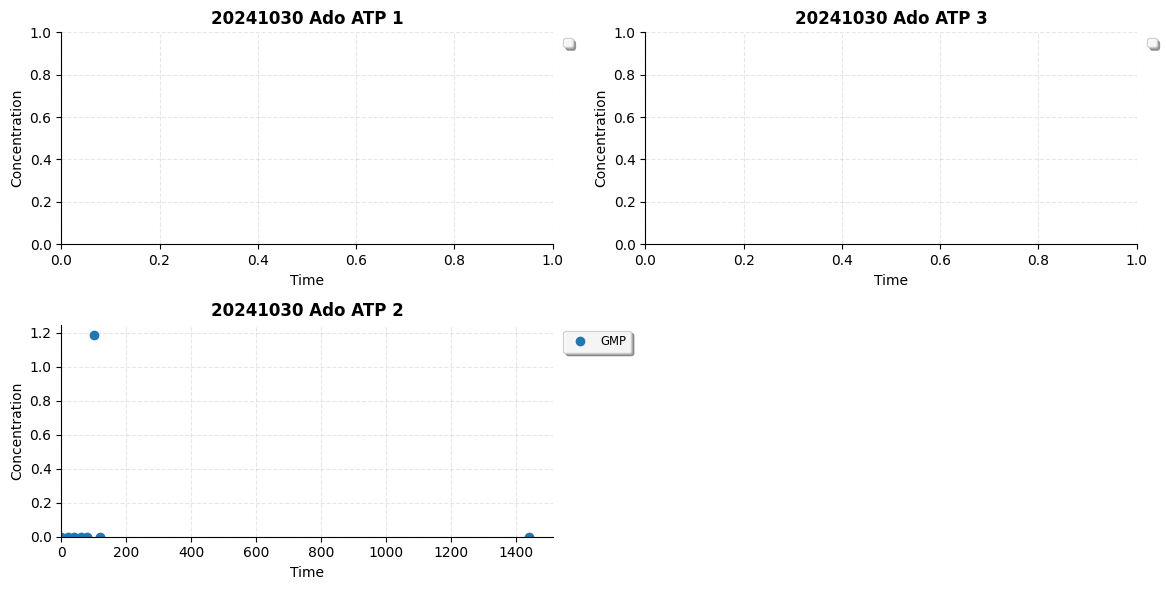

In [40]:
fig, ax = pe.plot(timecourse_enzymeML)
for axe in ax:
    axe.set_xlim(0)
    axe.set_ylim(0)

Furthermore, the `plot_replicates` function can be used to plot the replicates. It aggregates replicates and plots the mean±std per species as an errorbar plot. The function can be modified by manipulating the code in `utility/plot.py`.

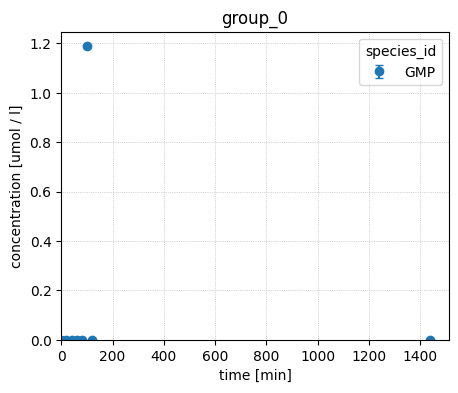

In [41]:
fig, axes = plot_replicates(timecourse_enzymeML)
for axe in axes:
    axe.set_xlim(0)
    axe.set_ylim(0)

fig.savefig("result/figures/replicates_overview.png", dpi=300)